# Modelos de difusión

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll
import torch
import torch.nn as nn
import torch.optim as optim

## Datos de entrenamiento

In [2]:
def get_batch(batch_size=1000, noise=0.1):
    x, _ = make_swiss_roll(batch_size, noise=noise)
    x = x[:, [0, 2]]
    x = (x - x.mean()) / x.std()
    return torch.tensor(x).float()

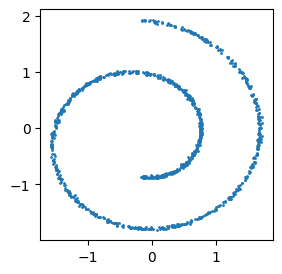

In [3]:
samples = get_batch()
plt.figure(figsize=(3, 3))
plt.scatter(samples[:, 0], samples[:, 1], s=1)
plt.show()

## Propiedades del proceso forward

### Proceso forward marginal $q(x_t|x_0)$

In [4]:
T = 5
alpha = torch.linspace(1, 0.9, T + 1)
alpha_bar = torch.cumprod(alpha, dim=0)

print(alpha.tolist())
print(alpha_bar.tolist())

def add_noise(x_0, t):
    epsilon = torch.randn_like(x_0)
    x_t = alpha_bar[t].sqrt() * x_0 + (1 - alpha_bar[t]).sqrt() * epsilon
    return x_t

[1.0, 0.9800000190734863, 0.9599999785423279, 0.9399999976158142, 0.9199999570846558, 0.8999999761581421]
[1.0, 0.9800000190734863, 0.9408000111579895, 0.8843519687652588, 0.8136038184165955, 0.7322434186935425]


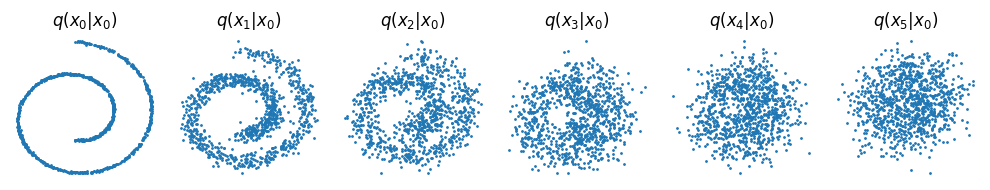

In [5]:
x_0 = get_batch()

plt.figure(figsize=(10, 2))
for t in range(T + 1):
    x_t = add_noise(x_0, t)
    plt.subplot(1, T+1, t+1)
    plt.scatter(x_t[:, 0], x_t[:, 1], s=1)
    plt.title(f'$q(x_{t}|x_0)$')
    plt.axis('off')

plt.tight_layout()
plt.show()

### Proceso backward condicional $q(x_{t-1}|x_t,x_0)$

In [6]:
def conditional_denoising(x_t, t, x_0):
    
    # Media:
    factor1 = alpha_bar[t-1].sqrt() * (1 - alpha[t]) / (1 - alpha_bar[t])
    factor2 = alpha[t].sqrt() * (1 - alpha_bar[t-1]) / (1 - alpha_bar[t])
    mu_q = factor1 * x_0 + factor2 * x_t

    # Varianza:
    sigma2_q = (1 - alpha[t]) * (1 - alpha_bar[t-1]) / (1 - alpha_bar[t])

    # Generación:
    epsilon = torch.rand_like(x_0)
    x_prev = mu_q + sigma2_q.sqrt() * epsilon

    return x_prev

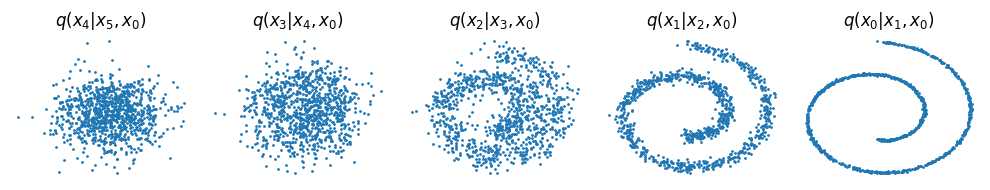

In [7]:
x_0 = get_batch()
x_t = torch.randn_like(x_0)  # muestras desde p(x_T) ≈ q(x_T).

plt.figure(figsize=(10, 2))
for t in reversed(range(1, T + 1)):  # t = T, T-1, ..., 1.
    plt.subplot(1, T, T - t + 1)
    x_t = conditional_denoising(x_t, t, x_0)
    plt.scatter(x_t[:, 0], x_t[:, 1], s=1)
    plt.title(f'$q(x_{t-1}|x_{t},x_0)$')
    plt.axis('off')

plt.tight_layout()
plt.show()

## Implementación de un modelo de difusión

### Clase `DM`

In [ ]:
class DM:

    def __init__(self, model, T=5, initial_alpha=1, final_alpha=0.95):
        self.model = model
        self.T = T
        self.alpha = torch.linspace(initial_alpha, final_alpha, T + 1).unsqueeze(1)  # shape: [T+1, 1].
        self.alpha_bar = torch.cumprod(self.alpha, dim=0)  # shape: [T+1, 1].

    def mu_q(self, x_0, x_t, t):
        factor1 = self.alpha_bar[t-1].sqrt() * (1 - self.alpha[t]) / (1 - self.alpha_bar[t])
        factor2 = self.alpha[t].sqrt() * (1 - self.alpha_bar[t-1]) / (1 - self.alpha_bar[t])
        mu_q = factor1 * x_0 + factor2 * x_t
        return mu_q

    def sigma2_q(self, t):
        sigma2_q = (1 - self.alpha[t]) * (1 - self.alpha_bar[t-1]) / (1 - self.alpha_bar[t])
        return sigma2_q

    def train(self, optimizer, iters=5000, batch_fn=get_batch):

        for _ in range(iters):

            x_0 = batch_fn()
            t = torch.randint(1, self.T + 1, size=[len(x_0)])  # Uniform[1, T].

            # Inyección de ruido:
            x_t = self.alpha_bar[t].sqrt() * x_0 + (1-self.alpha_bar[t]).sqrt() * torch.randn_like(x_0)

            # Error cuadrático medio:
            loss = (self.mu_q(x_0, x_t, t) - self.model(x_t, t)).norm(dim=-1) ** 2
            loss = loss.mean()

            # Optimización:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    
    def ancestral_sampling(self, n_samples, data_dim=2):

        x_t = torch.randn(n_samples, data_dim)  # x_T -> normal.
        
        for t in reversed(range(1, self.T + 1)):  # t = T, T-1, ..., 1.
            t_batch = t * torch.ones(n_samples)
            mu_theta = self.model(x_t, t_batch)
            sigma_q = self.sigma2_q(t).sqrt()
            x_t = mu_theta + sigma_q * torch.randn_like(x_t)

        return x_t.detach()

### Red neuronal

In [9]:
class DiffusionNetwork(nn.Module):

    def __init__(self, data_dim=2, hidden_dim=128):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(data_dim + 1, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, data_dim)
        )

    def forward(self, x_t, t):
        input = torch.cat([x_t, t.unsqueeze(1)], dim=1)
        mu_theta = self.model(input)
        return mu_theta

### Entrenamiento

In [10]:
model = DiffusionNetwork()
dm = DM(model)

optimizer = optim.AdamW(model.parameters())
dm.train(optimizer, iters=5000)

### Generación

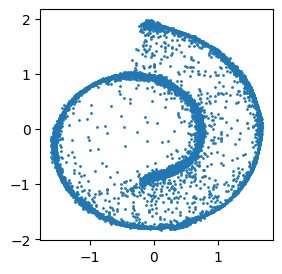

In [11]:
samples = dm.ancestral_sampling(n_samples=10000)
plt.figure(figsize=(3, 3))
plt.scatter(samples[:, 0], samples[:, 1], s=1)
plt.show()